In [3]:
# auto reload modules
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import wilcoxon, shapiro, friedmanchisquare, f_oneway, ttest_rel
from matplotlib.colors import to_rgba
import statsmodels.stats.multitest as smm
from globalVars import *
from load_data_pickles import *
from plotting_variables import TINY_SIZE

# --- shared boxplot layout constants (used across all figure cells) ---
boxplot_orders = ['passthrough\n'+r'$I = 1$', '0th-order\ninterface', '1st-order\ninterface', '2nd-order\ninterface']
box_labels_base = ['passthrough']
box_labels = ['initial', 'final', 'baseline']
loss_box_x = [0.82, 1.72, 3.15]          # x-positions: [initial, final, baseline] boxes
x_sep_final_baseline = 0.5 * (loss_box_x[1] + loss_box_x[2])  # divider line between adaptive and fixed-trial boxes
lw_box = 0.5

# lowest_x_freq: use only the 8 lowest stimulated frequencies for norm computations
# IX holds indices of all stimulated freqs in the full FFT array; IX[:8] selects the low-freq subset
lowest_x_freq = 8

# frequency-domain output norm at stimulated frequencies (subjects x conditions x trials)
Y_norm = np.linalg.norm(Ys[:,:,:,IX[:lowest_x_freq]], axis=3)
Y_base_norm = np.linalg.norm(Ys_base[:,:,IX[:lowest_x_freq]], axis=2)

# human input norm ||u_H||
UH_norm = np.linalg.norm(UHs[:,:,:,IX[:lowest_x_freq]], axis=3)
UH_base_norm = np.linalg.norm(UHs_base[:,:,IX[:lowest_x_freq]], axis=2)

# interface input norm ||u_I||
UI_norm = np.linalg.norm(UGs[:,:,:,:lowest_x_freq], axis=3)
UI_base_norm = np.linalg.norm(UGs_base[:,:,:lowest_x_freq], axis=2)

# interface cost: c_I(H,I) = (||y|| + lamH·||u_H|| + lamG·||u_I||) / ||d||
# lamH and lamG are regularization weights penalizing human effort and interface effort respectively
lamH = 1.5 # penalty on human effort
lamG = 0.5 # penalty on interface effort
D_norm = np.linalg.norm(np.asarray(Ds[:,:,:,IX[:lowest_x_freq]]), axis=3)
D_norm_base = np.linalg.norm(np.asarray(Ds_base[:,:,IX[:lowest_x_freq]]), axis=2)
interface_loss_freqdomain = (Y_norm + lamH*UH_norm + lamG*UI_norm) / D_norm
interface_loss_freqdomain_base = (Y_base_norm + lamH*UH_base_norm + lamG*UI_base_norm) / D_norm_base

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Stats

In [4]:
def style_bplot_passthrough(bplot, lw):
    """Style the single-box passthrough panel in black with white median."""
    c = 'black'
    bplot['boxes'][0].set_facecolor(to_rgba(c, alpha=0.5))
    bplot['boxes'][0].set_edgecolor(c)
    bplot['boxes'][0].set_linewidth(lw)
    for line in bplot['whiskers'] + bplot['caps']:
        line.set_color(c)
        line.set_linewidth(lw)
    for median in bplot['medians']:
        median.set_color('white')
        median.set_linewidth(lw)


def style_bplot(bplot, colors, lw):
    """Apply per-box colors and linewidth; resets baseline (3rd) box median to grey."""
    for i, (patch, color) in enumerate(zip(bplot['boxes'], colors)):
        patch.set_facecolor(to_rgba(color, alpha=0.5))
        patch.set_edgecolor(color)
        patch.set_linewidth(lw)
        bplot['whiskers'][2*i].set_color(color);   bplot['whiskers'][2*i].set_linewidth(lw)
        bplot['whiskers'][2*i+1].set_color(color); bplot['whiskers'][2*i+1].set_linewidth(lw)
        bplot['caps'][2*i].set_color(color);       bplot['caps'][2*i].set_linewidth(lw)
        bplot['caps'][2*i+1].set_color(color);     bplot['caps'][2*i+1].set_linewidth(lw)
        bplot['medians'][i].set_color(color)
        bplot['medians'][i].set_linewidth(lw)
    bplot['medians'][2].set_color('grey')  # baseline box median always grey
    bplot['medians'][2].set_linewidth(lw)


def pairwise_paired_ttests_bonferroni(comparisons, *, alpha=0.05, method='bonferroni', label=''):
    """Paired t-tests for each (name, d1, d2); print raw and multiplicity-adjusted p-values.

    comparisons : sequence of (name, d1, d2) with paired 1d arrays d1, d2.
    Returns list of dicts: name, p_raw, p_corr, reject.
    """
    p_raw_list = []
    for name, d1, d2 in comparisons:
        _, p_sw1 = shapiro(d1)
        _, p_sw2 = shapiro(d2)
        if (p_sw1 > 0.05) and (p_sw2 > 0.05):
            _stat, p_raw = stats.ttest_rel(d1, d2)
            test_used = 'ttest_rel'
        else:
            _stat, p_raw = wilcoxon(d1, d2)
            test_used = 'wilcoxon'
        p_raw_list.append(p_raw)
    reject, p_corr_arr, _, _ = smm.multipletests(p_raw_list, alpha=alpha, method=method)
    rows = []
    print(f"{test_used} tests + {method} (m={len(comparisons)}, alpha={alpha}):")
    for (name, _d1, _d2), p_raw, p_corr, rej in zip(comparisons, p_raw_list, p_corr_arr, reject):
        print(f"  {name}: p_raw={p_raw:.6f}, p_corr={p_corr:.6f}, significant={'yes' if rej else 'no'}")
        rows.append({'name': name, 'p_raw': float(p_raw), 'p_corr': float(p_corr), 'reject': bool(rej)})
    return rows


def plot_stats_lines(d1, d2, ax, bplot, box_x, i1, i2, level=0, *, y0, h, lw=0.5, print_ns=False, p_value=None):
    """Draw a significance bracket between boxes at indices i1 and i2.

    p_value: if None, runs ttest_rel internally; otherwise uses the provided value (e.g. Bonferroni-corrected).
    """
    if p_value is None:
        _, p = stats.ttest_rel(d1, d2)
    else:
        p = float(p_value)
    if p < 0.001:
        sig = '***'
    elif p < 0.01:
        sig = '**'
    elif p < 0.05:
        sig = '*'
    else:
        sig = 'ns'
    if sig == 'ns' and not print_ns:
        return float('-inf')
    x1, x2 = box_x[i1], box_x[i2]
    ax.plot([x1, x1, x2, x2], [y0, y0 + h, y0 + h, y0], color='black', lw=lw, clip_on=False)
    ax.text(
        (x1 + x2) / 2, y0 + h, sig,
        ha='center', va='bottom',
        fontsize=TINY_SIZE,
        fontweight='bold' if sig != 'ns' else 'normal',
        clip_on=False,
    )
    return y0 + h


def stats_test_multiple_groups(datas):
    """ANOVA (or Friedman if non-normal) across 4 groups with Bonferroni post-hoc tests vs. group 0."""
    p_sw_list = []
    for i in range(len(datas)):
        _, p_sw = shapiro(datas[i])
        p_sw_list.append(p_sw)

    if all(p_sw_list) > 0.05:  # all groups normally distributed
        print("Residuals appear to be normally distributed (fail to reject H0).")
        stat, p = f_oneway(datas[0], datas[1], datas[2], datas[3])
        print(f'One-way ANOVA Statistic={stat:.4f}, p-value={p:.4f}')
        if p <= 0.05:
            print('ANOVA Test: significant difference. Do paired t-tests')
            comparisons = [
                ("cond1 vs. cond0", datas[0], datas[1]),
                ("cond2 vs. cond0", datas[0], datas[2]),
                ("cond3 vs. cond0", datas[0], datas[3]),
            ]
            p_values, t_stats = [], []
            for name, cond1, cond2 in comparisons:
                stat, p = ttest_rel(cond1, cond2)
                p_values.append(p)
                t_stats.append(stat)
            corrected_p_values = smm.multipletests(p_values, method='bonferroni')[1]
            for (name, _, _), p_raw, p_corr, t_stat in zip(comparisons, p_values, corrected_p_values, t_stats):
                print(f'{name}: stat = {t_stat}, Raw p-value = {p_raw:.4f}, Bonferroni-corrected p-value = {p_corr:.4f}')
    else:
        print("Residuals are NOT normally distributed (reject H0).")
        stat, p = friedmanchisquare(datas[0], datas[1], datas[2], datas[3])
        print(f'Friedman Test Statistic={stat:.4f}, p-value={p:.4f}')
        if p <= 0.05:
            print('Friedman Test: significant difference')
            comparisons = [
                ("cond1 vs. cond0", datas[0], datas[1]),
                ("cond2 vs. cond0", datas[0], datas[2]),
                ("cond3 vs. cond0", datas[0], datas[3]),
            ]
            p_values, t_stats = [], []
            for name, cond1, cond2 in comparisons:
                stat, p = wilcoxon(cond1, cond2)
                p_values.append(p)
                t_stats.append(stat)
            corrected_p_values = smm.multipletests(p_values, method='bonferroni')[1]
            for (name, _, _), p_raw, p_corr, t_stat in zip(comparisons, p_values, corrected_p_values, t_stats):
                print(f'{name}: stat = {t_stat}, Raw p-value = {p_raw:.4f}, Bonferroni-corrected p-value = {p_corr:.4f}')
        else:
            print('Friedman Test: no significant difference')

# Task error

ttest_rel tests + bonferroni (m=1, alpha=0.05):
  final vs baseline: p_raw=0.000041, p_corr=0.000041, significant=yes
ttest_rel tests + bonferroni (m=1, alpha=0.05):
  final vs baseline: p_raw=0.139446, p_corr=0.139446, significant=no
ttest_rel tests + bonferroni (m=1, alpha=0.05):
  final vs baseline: p_raw=0.647967, p_corr=0.647967, significant=no


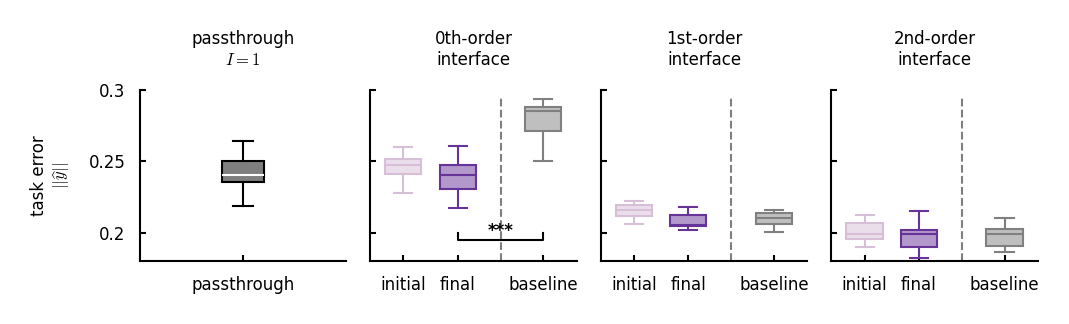



Residuals appear to be normally distributed (fail to reject H0).
One-way ANOVA Statistic=59.4764, p-value=0.0000
ANOVA Test: significant difference. Do paired t-tests
cond1 vs. cond0: stat = -6.480222199261137, Raw p-value = 0.0001, Bonferroni-corrected p-value = 0.0002
cond2 vs. cond0: stat = 7.131223710192027, Raw p-value = 0.0000, Bonferroni-corrected p-value = 0.0001
cond3 vs. cond0: stat = 11.38026043936787, Raw p-value = 0.0000, Bonferroni-corrected p-value = 0.0000


In [5]:
# task error ||ŷ||: normalized output at stimulated frequencies
# data[0]=initial (trials 3-5), data[1]=final (trials 15-17), data[2]=baseline (fixed trials [0,1,2,18,19,20])
boxcolors = ['thistle', 'rebeccapurple', 'grey']
ylim_loss = (0.18, 0.295)

fig, axs = plt.subplots(1, 4, sharey=True, figsize=(3.5, 1), dpi=300)
for col, panel_title in enumerate(boxplot_orders):
    ax = axs[col]
    if col == 0:
        bplot = ax.boxplot([np.mean(Y_base_norm, axis=1)], tick_labels=box_labels_base, widths=0.6/3, patch_artist=True, showfliers=False)
        ax.set_title(panel_title)
        style_bplot_passthrough(bplot, lw_box)
    else:
        L = Y_norm[:, col - 1, :]
        data = [
            np.mean(L[:, 3:6], axis=1),
            np.mean(L[:, 15:18], axis=1),
            np.mean(L[:, [0,1,2,18,19,20]], axis=1),
        ]
        bplot = ax.boxplot(data, positions=loss_box_x, tick_labels=box_labels, widths=0.6, patch_artist=True, showfliers=False)
        ax.set_title(panel_title)
        ax.set_xlim(loss_box_x[0] - 0.55, loss_box_x[2] + 0.55)
        style_bplot(bplot, boxcolors, lw_box)

        comp_loss = [("final vs baseline", data[1], data[2])]
        p_bonf_loss = pairwise_paired_ttests_bonferroni(comp_loss, label=f"{panel_title}: ")
        plot_stats_lines(data[1], data[2], ax, bplot, loss_box_x, 1, 2, y0=0.2, h=-0.005, p_value=p_bonf_loss[0]['p_corr'])
        ax.set_ylim(*ylim_loss)
    ax.tick_params(axis='x', labelsize=4)
    ax.tick_params(direction="in")

for j in [1, 2, 3]:
    ylim = axs[j].get_ylim()
    axs[j].plot([x_sep_final_baseline, x_sep_final_baseline], ylim, color='black', linestyle='--', alpha=0.5, linewidth=0.5)

axs[0].set_ylim(*ylim_loss)
yticks_shared = [0.20, 0.25, 0.3]
axs[0].set_yticks(yticks_shared)
axs[0].set_yticklabels([0.2, 0.25, 0.3])
axs[0].set_ylabel('task error\n'+r'$||\widehat{y}||$')
for idx in (1, 2, 3):
    axs[idx].set_yticks(yticks_shared)
    axs[idx].tick_params(axis='y', which='both', labelleft=False)
plt.tight_layout()
plt.show()

# 1-way anova tests between passthrough and 3 baselines
print('\n')
datas = [
    np.mean(Y_base_norm, axis=1),
    np.mean(Y_norm[:, 0, :][:, [0,1,2,18,19,20]], axis=1),
    np.mean(Y_norm[:, 1, :][:, [0,1,2,18,19,20]], axis=1),
    np.mean(Y_norm[:, 2, :][:, [0,1,2,18,19,20]], axis=1),
]
stats_test_multiple_groups(datas)

# Human effort

wilcoxon tests + bonferroni (m=1, alpha=0.05):
  final vs baseline: p_raw=0.001953, p_corr=0.001953, significant=yes
ttest_rel tests + bonferroni (m=1, alpha=0.05):
  final vs baseline: p_raw=0.002284, p_corr=0.002284, significant=yes
ttest_rel tests + bonferroni (m=1, alpha=0.05):
  final vs baseline: p_raw=0.003597, p_corr=0.003597, significant=yes


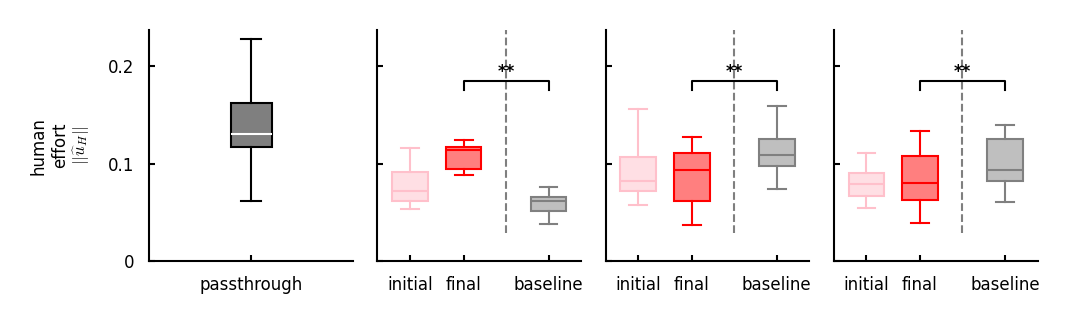



Residuals appear to be normally distributed (fail to reject H0).
One-way ANOVA Statistic=10.8033, p-value=0.0000
ANOVA Test: significant difference. Do paired t-tests
cond1 vs. cond0: stat = 7.153970529448427, Raw p-value = 0.0000, Bonferroni-corrected p-value = 0.0001
cond2 vs. cond0: stat = 5.021878272898159, Raw p-value = 0.0005, Bonferroni-corrected p-value = 0.0016
cond3 vs. cond0: stat = 6.930293347205915, Raw p-value = 0.0000, Bonferroni-corrected p-value = 0.0001


In [6]:
# human effort ||û_H||: human input norm at stimulated frequencies
boxcolors = ['pink', 'red', 'grey']

fig, axs = plt.subplots(1, 4, sharey=True, figsize=(3.5, 1), dpi=300)
for col, panel_title in enumerate(boxplot_orders):
    ax = axs[col]
    if col == 0:
        bplot = ax.boxplot([np.mean(UH_base_norm, axis=1)], tick_labels=box_labels_base, widths=0.6/3, patch_artist=True, showfliers=False)
        style_bplot_passthrough(bplot, lw_box)
    else:
        L = UH_norm[:, col - 1, :]
        data = [
            np.mean(L[:, 3:6], axis=1),
            np.mean(L[:, 15:18], axis=1),
            np.mean(L[:, [0,1,2,18,19,20]], axis=1),
        ]
        bplot = ax.boxplot(data, positions=loss_box_x, tick_labels=box_labels, widths=0.6, patch_artist=True, showfliers=False)
        ax.set_xlim(loss_box_x[0] - 0.55, loss_box_x[2] + 0.55)
        style_bplot(bplot, boxcolors, lw_box)

        y_lo0, y_hi0 = ax.get_ylim()
        y_rng0 = y_hi0 - y_lo0
        comp_loss = [("final vs baseline", data[1], data[2])]
        p_bonf_loss = pairwise_paired_ttests_bonferroni(comp_loss, label=f"{panel_title}: ")
        tops = [
            plot_stats_lines(data[1], data[2], ax, bplot, loss_box_x, 1, 2, y0=0.175, h=0.01, p_value=p_bonf_loss[0]['p_corr']),
        ]
        ax.set_ylim(y_lo0, max(y_hi0, max(tops) + 0.1 * y_rng0))
    ax.tick_params(axis='x', labelsize=4)
    ax.tick_params(direction="in")

y_lo_all = min(axs[k].get_ylim()[0] for k in range(4))
y_hi_all = max(axs[k].get_ylim()[1] for k in range(4))
for ax in axs:
    ax.set_ylim(y_lo_all, y_hi_all)

for j in [1, 2, 3]:
    ylim = axs[j].get_ylim()
    axs[j].plot([x_sep_final_baseline, x_sep_final_baseline], ylim, color='black', linestyle='--', alpha=0.5, linewidth=0.5)

yticks_shared = [0, 0.1, 0.2]
axs[0].set_yticks(yticks_shared)
axs[0].set_yticklabels([0, 0.1, 0.2])
axs[0].set_ylabel('human\neffort\n'+r'$||\widehat{u}_H||$')
for idx in (1, 2, 3):
    axs[idx].set_yticks(yticks_shared)
    axs[idx].tick_params(axis='y', which='both', labelleft=False)
plt.tight_layout()
plt.show()

# 1-way anova tests between passthrough and 3 baselines
print('\n')

datas = [
    np.mean(UH_base_norm, axis=1),
    np.mean(UH_norm[:, 0, :][:, [0,1,2,18,19,20]], axis=1),
    np.mean(UH_norm[:, 1, :][:, [0,1,2,18,19,20]], axis=1),
    np.mean(UH_norm[:, 2, :][:, [0,1,2,18,19,20]], axis=1),
]
stats_test_multiple_groups(datas)

# Interface effort

ttest_rel tests + bonferroni (m=1, alpha=0.05):
  final vs baseline: p_raw=0.000015, p_corr=0.000015, significant=yes
ttest_rel tests + bonferroni (m=1, alpha=0.05):
  final vs baseline: p_raw=0.043872, p_corr=0.043872, significant=yes
ttest_rel tests + bonferroni (m=1, alpha=0.05):
  final vs baseline: p_raw=0.047758, p_corr=0.047758, significant=yes


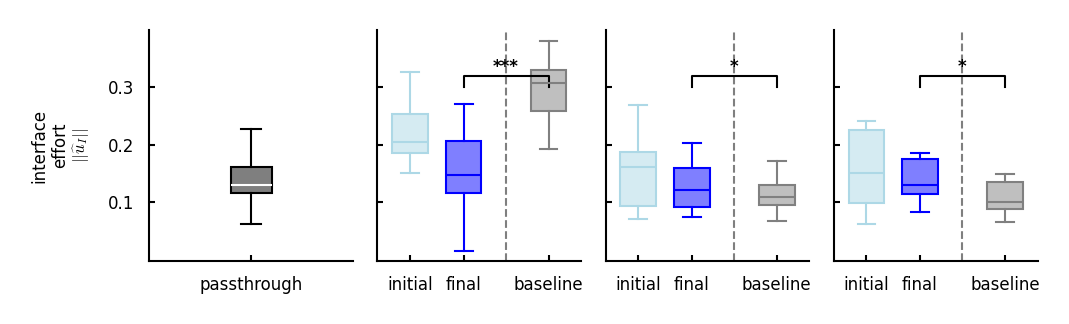



Residuals appear to be normally distributed (fail to reject H0).
One-way ANOVA Statistic=40.2608, p-value=0.0000
ANOVA Test: significant difference. Do paired t-tests
cond1 vs. cond0: stat = -12.464007624418716, Raw p-value = 0.0000, Bonferroni-corrected p-value = 0.0000
cond2 vs. cond0: stat = 6.890962599501146, Raw p-value = 0.0000, Bonferroni-corrected p-value = 0.0001
cond3 vs. cond0: stat = 5.347235113720469, Raw p-value = 0.0003, Bonferroni-corrected p-value = 0.0010


In [7]:
# interface effort ||û_I||: interface input norm at stimulated frequencies
boxcolors = ['lightblue', 'blue', 'grey']

fig, axs = plt.subplots(1, 4, sharey=True, figsize=(3.5, 1), dpi=300)
for col, panel_title in enumerate(boxplot_orders):
    ax = axs[col]
    if col == 0:
        bplot = ax.boxplot([np.mean(UI_base_norm, axis=1)], tick_labels=box_labels_base, widths=0.6/3, patch_artist=True, showfliers=False)
        style_bplot_passthrough(bplot, lw_box)
    else:
        L = UI_norm[:, col - 1, :]
        data = [
            np.mean(L[:, 3:6], axis=1),
            np.mean(L[:, 15:18], axis=1),
            np.mean(L[:, [0,1,2,18,19,20]], axis=1),
        ]
        bplot = ax.boxplot(data, positions=loss_box_x, tick_labels=box_labels, widths=0.6, patch_artist=True, showfliers=False)
        ax.set_xlim(loss_box_x[0] - 0.55, loss_box_x[2] + 0.55)
        style_bplot(bplot, boxcolors, lw_box)

        y_lo0, y_hi0 = ax.get_ylim()
        y_rng0 = y_hi0 - y_lo0
        comp_loss = [("final vs baseline", data[1], data[2])]
        p_bonf_loss = pairwise_paired_ttests_bonferroni(comp_loss, label=f"{panel_title}: ")
        tops = [
            plot_stats_lines(data[1], data[2], ax, bplot, loss_box_x, 1, 2, y0=0.3, h=0.02, p_value=p_bonf_loss[0]['p_corr']),
        ]
        ax.set_ylim(y_lo0, max(y_hi0, max(tops) + 0.1 * y_rng0))
    ax.tick_params(axis='x', labelsize=4)
    ax.tick_params(direction="in")

y_lo_all = min(axs[k].get_ylim()[0] for k in range(4))
y_hi_all = max(axs[k].get_ylim()[1] for k in range(4))
for ax in axs:
    ax.set_ylim(y_lo_all, y_hi_all)

for j in [1, 2, 3]:
    ylim = axs[j].get_ylim()
    axs[j].plot([x_sep_final_baseline, x_sep_final_baseline], ylim, color='black', linestyle='--', alpha=0.5, linewidth=0.5)

yticks_shared = [0.1, 0.2, 0.3]
axs[0].set_yticks(yticks_shared)
axs[0].set_yticklabels([0.1, 0.2, 0.3])
axs[0].set_ylabel('interface\neffort\n'+r'$||\widehat{u}_I||$')
for idx in (1, 2, 3):
    axs[idx].set_yticks(yticks_shared)
    axs[idx].tick_params(axis='y', which='both', labelleft=False)
plt.tight_layout()
plt.show()


# 1-way anova tests between passthrough and 3 baselines
print('\n')
datas = [
    np.mean(UI_base_norm, axis=1),
    np.mean(UI_norm[:, 0, :][:, [0,1,2,18,19,20]], axis=1),
    np.mean(UI_norm[:, 1, :][:, [0,1,2,18,19,20]], axis=1),
    np.mean(UI_norm[:, 2, :][:, [0,1,2,18,19,20]], axis=1),
]
stats_test_multiple_groups(datas)

# Interface cost

ttest_rel tests + bonferroni (m=1, alpha=0.05):
  final vs baseline: p_raw=0.012932, p_corr=0.012932, significant=yes
ttest_rel tests + bonferroni (m=1, alpha=0.05):
  final vs baseline: p_raw=0.048296, p_corr=0.048296, significant=yes
ttest_rel tests + bonferroni (m=1, alpha=0.05):
  final vs baseline: p_raw=0.104440, p_corr=0.104440, significant=no


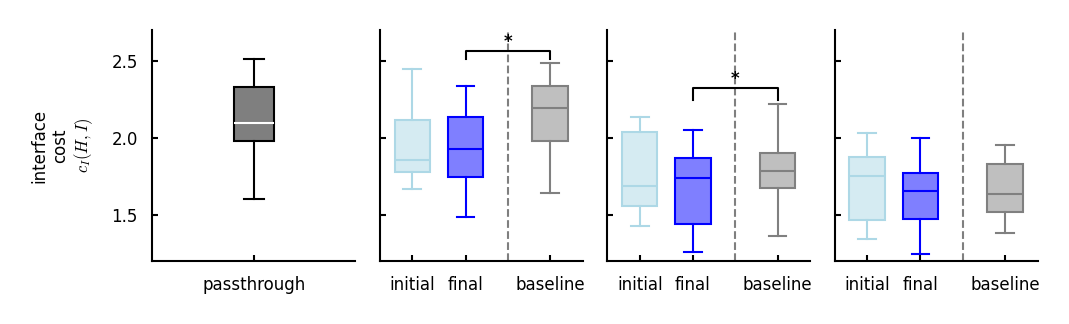



Residuals appear to be normally distributed (fail to reject H0).
One-way ANOVA Statistic=6.9412, p-value=0.0007
ANOVA Test: significant difference. Do paired t-tests
cond1 vs. cond0: stat = 0.09697855353972386, Raw p-value = 0.9247, Bonferroni-corrected p-value = 1.0000
cond2 vs. cond0: stat = 8.755548431308055, Raw p-value = 0.0000, Bonferroni-corrected p-value = 0.0000
cond3 vs. cond0: stat = 9.979816201359963, Raw p-value = 0.0000, Bonferroni-corrected p-value = 0.0000


In [8]:
# interface cost c_I(H,I) = (||y|| + lamH·||u_H|| + lamG·||u_I||) / ||d||
boxcolors = ['lightblue', 'blue', 'grey']
ylim_interface = (1.2, 2.7)

fig, axs = plt.subplots(1, 4, sharey=True, figsize=(3.5, 1), dpi=300)
for col, panel_title in enumerate(boxplot_orders):
    ax = axs[col]
    if col == 0:
        bplot = ax.boxplot([np.mean(interface_loss_freqdomain_base, axis=1)], tick_labels=box_labels_base, widths=0.6/3, patch_artist=True, showfliers=False)
        style_bplot_passthrough(bplot, lw_box)
    else:
        L = interface_loss_freqdomain[:, col - 1, :]
        data = [
            np.mean(L[:, 3:6], axis=1),
            np.mean(L[:, 15:18], axis=1),
            np.mean(L[:, [0,1,2,18,19,20]], axis=1),
        ]
        bplot = ax.boxplot(data, positions=loss_box_x, tick_labels=box_labels, widths=0.6, patch_artist=True, showfliers=False)
        ax.set_xlim(loss_box_x[0] - 0.55, loss_box_x[2] + 0.55)
        style_bplot(bplot, boxcolors, lw_box)

        y_lo, y_hi = ax.get_ylim()
        y_rng = y_hi - y_lo
        cap_top = max(
            float(bplot['caps'][2 * 1 + 1].get_ydata().max()),
            float(bplot['caps'][2 * 2 + 1].get_ydata().max()),
        )
        h = y_rng * 0.05
        y0 = cap_top + y_rng * 0.018
        comp_loss = [("final vs baseline", data[1], data[2])]
        p_bonf_loss = pairwise_paired_ttests_bonferroni(comp_loss, label=f"{panel_title}: ")
        plot_stats_lines(data[1], data[2], ax, bplot, loss_box_x, 1, 2, y0=y0, h=h, p_value=p_bonf_loss[0]['p_corr'])
        ax.set_ylim(*ylim_interface)
    ax.tick_params(axis='x', labelsize=4)
    ax.tick_params(direction="in")

for j in [1, 2, 3]:
    ylim = axs[j].get_ylim()
    axs[j].plot([x_sep_final_baseline, x_sep_final_baseline], ylim, color='black', linestyle='--', alpha=0.5, linewidth=0.5)

axs[0].set_ylim(*ylim_interface)
yticks_shared = [1.5, 2.0, 2.5]
axs[0].set_yticks(yticks_shared)
axs[0].set_yticklabels([1.5, 2.0, 2.5])
axs[0].set_ylabel('interface\ncost\n'+r'$c_I(H,I)$')
for idx in (1, 2, 3):
    axs[idx].set_yticks(yticks_shared)
    axs[idx].tick_params(axis='y', which='both', labelleft=False)
plt.tight_layout()
plt.show()

# 1-way anova tests between passthrough and 3 baselines
print('\n')

# anova tests between passthrough and 3 baselines
datas = [
    np.mean(interface_loss_freqdomain_base, axis=1),
    np.mean(interface_loss_freqdomain[:, 0, :][:, [0,1,2,18,19,20]], axis=1),
    np.mean(interface_loss_freqdomain[:, 1, :][:, [0,1,2,18,19,20]], axis=1),
    np.mean(interface_loss_freqdomain[:, 2, :][:, [0,1,2,18,19,20]], axis=1),
]
stats_test_multiple_groups(datas)

# Stability margin

In [9]:
def compute_smallest_distance(L_vals):
    """Nyquist stability margin: smallest distance from the open-loop response L(iω) to the critical point -1.
    L_vals: complex array of H·M·I evaluated at stimulated frequencies.
    """
    distances = np.abs(L_vals + 1)  # |L(iω) - (-1)| at each stimulated frequency
    idx_min = np.argmin(distances)
    min_dist = float(distances[idx_min])
    w_min = float(freqs[idx_min])
    return min_dist, w_min


# soM = discrete plant M transfer function evaluated at stimulated frequencies (from globalVars)
L_min_distance = np.zeros((subject_num, condition_num, trial_num))
for sub in range(subject_num):
    for cond in range(condition_num):
        for trial in range(trial_num):
            L_example = Hs[sub, cond, trial, IX] * soM * Gs[sub, cond, trial]  # open-loop: H·M·I
            min_dist, _ = compute_smallest_distance(L_example)
            L_min_distance[sub, cond, trial] = min_dist

L_min_distance_base = np.zeros((subject_num, trial_num_base))
for sub in range(subject_num):
    for trial in range(trial_num_base):
        L_example = Hs_base[sub, trial, IX] * soM * Gs_base[sub, trial]
        min_dist, _ = compute_smallest_distance(L_example)
        L_min_distance_base[sub, trial] = min_dist

print(L_min_distance.shape)
print(L_min_distance_base.shape)

(11, 3, 21)
(11, 12)


wilcoxon tests + bonferroni (m=1, alpha=0.05):
  final vs baseline: p_raw=0.001953, p_corr=0.001953, significant=yes
ttest_rel tests + bonferroni (m=1, alpha=0.05):
  final vs baseline: p_raw=0.294211, p_corr=0.294211, significant=no
ttest_rel tests + bonferroni (m=1, alpha=0.05):
  final vs baseline: p_raw=0.029523, p_corr=0.029523, significant=yes


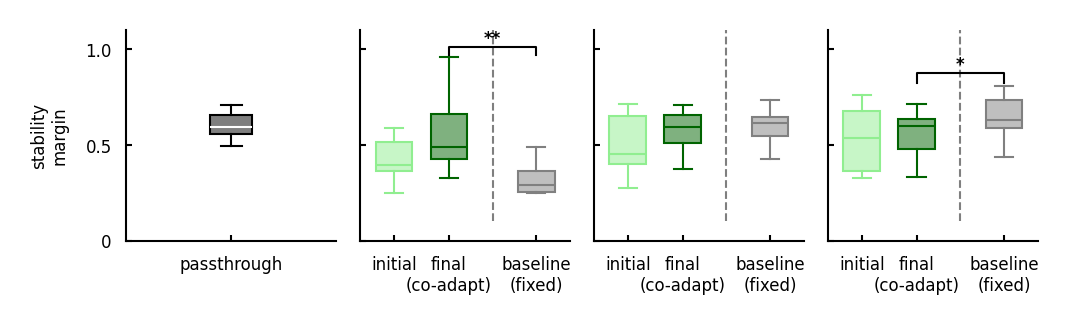



Residuals appear to be normally distributed (fail to reject H0).
One-way ANOVA Statistic=21.5220, p-value=0.0000
ANOVA Test: significant difference. Do paired t-tests
cond1 vs. cond0: stat = 9.378884316394199, Raw p-value = 0.0000, Bonferroni-corrected p-value = 0.0000
cond2 vs. cond0: stat = -0.5830529770730764, Raw p-value = 0.5728, Bonferroni-corrected p-value = 1.0000
cond3 vs. cond0: stat = -2.4927067703006447, Raw p-value = 0.0318, Bonferroni-corrected p-value = 0.0955


In [10]:
# stability margin: min |L(iω) + 1| over stimulated frequencies (Nyquist distance to -1)
box_labels = ['initial', 'final\n(co-adapt)', 'baseline\n(fixed)']  # override: longer labels for this panel
boxcolors = ['lightgreen', 'darkgreen', 'grey']
ylim_interface = (0.1, 1.1)

fig, axs = plt.subplots(1, 4, sharey=True, figsize=(3.5, 1), dpi=300)
for col, panel_title in enumerate(boxplot_orders):
    ax = axs[col]
    if col == 0:
        bplot = ax.boxplot([np.mean(L_min_distance_base, axis=1)], tick_labels=box_labels_base, widths=0.6/3, patch_artist=True, showfliers=False)
        style_bplot_passthrough(bplot, lw_box)
    else:
        L = L_min_distance[:, col - 1, :]
        data = [
            np.mean(L[:, 3:6], axis=1),
            np.mean(L[:, 15:18], axis=1),
            np.mean(L[:, [0,1,2,18,19,20]], axis=1),
        ]
        bplot = ax.boxplot(data, positions=loss_box_x, tick_labels=box_labels, widths=0.6, patch_artist=True, showfliers=False)
        ax.set_xlim(loss_box_x[0] - 0.55, loss_box_x[2] + 0.55)
        style_bplot(bplot, boxcolors, lw_box)

        y_lo, y_hi = ax.get_ylim()
        y_rng = y_hi - y_lo
        cap_top = max(
            float(bplot['caps'][2 * 1 + 1].get_ydata().max()),
            float(bplot['caps'][2 * 2 + 1].get_ydata().max()),
        )
        h = y_rng * 0.05
        y0 = cap_top + y_rng * 0.018
        comp_loss = [("final vs baseline", data[1], data[2])]
        p_bonf_loss = pairwise_paired_ttests_bonferroni(comp_loss, label=f"{panel_title}: ")
        plot_stats_lines(data[1], data[2], ax, bplot, loss_box_x, 1, 2, y0=y0, h=h, p_value=p_bonf_loss[0]['p_corr'])
        ax.set_ylim(*ylim_interface)
    ax.tick_params(axis='x', labelsize=4)
    ax.tick_params(direction="in")

for j in [1, 2, 3]:
    ylim = axs[j].get_ylim()
    axs[j].plot([x_sep_final_baseline, x_sep_final_baseline], ylim, color='black', linestyle='--', alpha=0.5, linewidth=0.5)

axs[0].set_ylim(*ylim_interface)
yticks_shared = [0, 0.5, 1.0]
axs[0].set_yticks(yticks_shared)
axs[0].set_yticklabels([0, 0.5, 1.0])
axs[0].set_ylabel('stability\nmargin')
for idx in (1, 2, 3):
    axs[idx].set_yticks(yticks_shared)
    axs[idx].tick_params(axis='y', which='both', labelleft=False)
plt.tight_layout()
plt.show()

# 1-way anova tests between passthrough and 3 baselines
print('\n')
datas = [
    np.mean(L_min_distance_base, axis=1),
    np.mean(L_min_distance[:, 0, :][:, [0,1,2,18,19,20]], axis=1),
    np.mean(L_min_distance[:, 1, :][:, [0,1,2,18,19,20]], axis=1),
    np.mean(L_min_distance[:, 2, :][:, [0,1,2,18,19,20]], axis=1),
]
stats_test_multiple_groups(datas)
